In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Check if the current `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# is available, and if not, use the CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [2]:
# Below we are preprocessing data for CIFAR-10. We use an arbitrary batch size of 128.
transforms_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
# Loading the CIFAR-10 dataset:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms_cifar)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms_cifar)

100%|██████████| 170M/170M [23:10<00:00, 123kB/s]


In [3]:
#Dataloaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [4]:
# Deeper neural network class to be used as teacher:
class DeepNN(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Lightweight neural network class to be used as student:
class LightNN(nn.Module):
    def __init__(self, num_classes=10):
        super(LightNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [5]:
import copy

def train(model, train_loader, val_loader, epochs, learning_rate, device, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(epochs):

        # =========================
        # Training
        # =========================
        model.train()

        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # =========================
        # Validation
        # =========================
        model.eval()

        val_loss = 0.0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        print(
            f"Epoch {epoch+1}/{epochs}, "
            f"Train Loss: {train_loss:.4f}, "
            f"Val Loss: {val_loss:.4f}"
        )

        # =========================
        # Early Stopping
        # =========================
        if val_loss < best_val_loss:

            # Validation improved
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

            patience_counter = 0

        else:

            # No improvement
            patience_counter += 1

            print(
                f"No improvement for "
                f"{patience_counter}/{patience} epochs"
            )

            if patience_counter >= patience:
                print("Early stopping triggered!")
                break

    # Restore the best model
    model.load_state_dict(best_model_state)


def test(model, test_loader, device):
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Test Accuracy: {accuracy:.2f}%")

    return accuracy

In [6]:
torch.manual_seed(42)
nn_deep = DeepNN(num_classes=10).to(device)
train(nn_deep, train_loader, epochs=100, learning_rate=0.001, device=device)
test_accuracy_deep = test(nn_deep, test_loader, device)

# Instantiate the lightweight network:
torch.manual_seed(42)
nn_light = LightNN(num_classes=10).to(device)

Epoch 1/100, Loss: 1.3003498611547757
Epoch 2/100, Loss: 0.8351294867827764
Epoch 3/100, Loss: 0.6625904156957441
Epoch 4/100, Loss: 0.5246177543612087
Epoch 5/100, Loss: 0.4067486458936768
Epoch 6/100, Loss: 0.3119621290479932
Epoch 7/100, Loss: 0.23703253048155315
Epoch 8/100, Loss: 0.18789614960217796
Epoch 9/100, Loss: 0.16541000110957096
Epoch 10/100, Loss: 0.14121043777612546
Epoch 11/100, Loss: 0.1278805444410066
Epoch 12/100, Loss: 0.12048477135584368
Epoch 13/100, Loss: 0.11594085457444171
Epoch 14/100, Loss: 0.1057472603188356
Epoch 15/100, Loss: 0.10144213087501866
Epoch 16/100, Loss: 0.0929238368736823
Epoch 17/100, Loss: 0.09245582894258954
Epoch 18/100, Loss: 0.09267393182522482
Epoch 19/100, Loss: 0.08676264372289828
Epoch 20/100, Loss: 0.0817919171163979
Epoch 21/100, Loss: 0.07496472902189882
Epoch 22/100, Loss: 0.09019205300271382
Epoch 23/100, Loss: 0.07701970064876211
Epoch 24/100, Loss: 0.07676967353027973
Epoch 25/100, Loss: 0.08317425683238412
Epoch 26/100, Loss:

In [8]:
torch.manual_seed(42)
new_nn_light = LightNN(num_classes=10).to(device)

In [9]:
# Print the norm of the first layer of the initial lightweight model
print("Norm of 1st layer of nn_light:", torch.norm(nn_light.features[0].weight).item())
# Print the norm of the first layer of the new lightweight model
print("Norm of 1st layer of new_nn_light:", torch.norm(new_nn_light.features[0].weight).item())

Norm of 1st layer of nn_light: 2.327361822128296
Norm of 1st layer of new_nn_light: 2.327361822128296


In [10]:
total_params_deep = "{:,}".format(sum(p.numel() for p in nn_deep.parameters()))
print(f"DeepNN parameters: {total_params_deep}")
total_params_light = "{:,}".format(sum(p.numel() for p in nn_light.parameters()))
print(f"LightNN parameters: {total_params_light}")

DeepNN parameters: 1,186,986
LightNN parameters: 267,738


In [11]:
train(nn_light, train_loader, epochs=10, learning_rate=0.001, device=device)
test_accuracy_light_ce = test(nn_light, test_loader, device)

Epoch 1/10, Loss: 1.4021829748550034
Epoch 2/10, Loss: 1.0819881462380099
Epoch 3/10, Loss: 0.940604326746348
Epoch 4/10, Loss: 0.844679187097208
Epoch 5/10, Loss: 0.7616420325720706
Epoch 6/10, Loss: 0.6893514419531883
Epoch 7/10, Loss: 0.6231951134284134
Epoch 8/10, Loss: 0.5566521589941991
Epoch 9/10, Loss: 0.5056343146068666
Epoch 10/10, Loss: 0.4549478298181768
Test Accuracy: 70.11%


In [12]:
print(f"Teacher accuracy: {test_accuracy_deep:.2f}%")
print(f"Student accuracy: {test_accuracy_light_ce:.2f}%")

Teacher accuracy: 74.37%
Student accuracy: 70.11%


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


def train_knowledge_distillation(
    teacher,
    student,
    train_loader,
    test_loader,
    epochs,
    learning_rate,
    T,
    soft_target_loss_weight,
    ce_loss_weight,
    device
):
    ce_loss = nn.CrossEntropyLoss()
    optimizer = optim.Adam(student.parameters(), lr=learning_rate)

    teacher.eval()
    student.train()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        # =========================
        # Training
        # =========================
        student.train()

        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Teacher forward pass
            with torch.no_grad():
                teacher_logits = teacher(inputs)

            # Student forward pass
            student_logits = student(inputs)

            # Soft targets
            soft_targets = nn.functional.softmax(
                teacher_logits / T, dim=-1
            )

            soft_prob = nn.functional.log_softmax(
                student_logits / T, dim=-1
            )

            # KD loss
            soft_targets_loss = F.kl_div(
            soft_prob,       # log_softmax output (student)
            soft_targets,    # softmax output     (teacher)
            reduction='batchmean'
            ) * (T ** 2)

            # CE loss
            label_loss = ce_loss(student_logits, labels)

            # Combined loss
            loss = (
                soft_target_loss_weight * soft_targets_loss
                + ce_loss_weight * label_loss
            )

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # =========================
        # Test loss
        # =========================
        student.eval()

        running_test_loss = 0.0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = student(inputs)

                loss = ce_loss(outputs, labels)

                running_test_loss += loss.item()

        test_loss = running_test_loss / len(test_loader)

        # Save losses
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        print(
            f"Epoch {epoch+1}/{epochs}, "
            f"Train Loss: {train_loss:.4f}, "
            f"Test Loss: {test_loss:.4f}"
        )

    return train_losses, test_losses


# Apply ``train_knowledge_distillation`` with a temperature of 2. Arbitrarily set the weights to 0.75 for CE and 0.25 for distillation loss.
train_losses, test_losses = train_knowledge_distillation(
    teacher=nn_deep,
    student=new_nn_light,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=10,
    learning_rate=0.001,
    T=2,
    soft_target_loss_weight=0.25,
    ce_loss_weight=0.75,
    device=device
)

test_accuracy_light_ce_and_kd = test(new_nn_light, test_loader, device)

# Compare the student test accuracy with and without the teacher, after distillation
print(f"Teacher accuracy: {test_accuracy_deep:.2f}%")
print(f"Student accuracy without teacher: {test_accuracy_light_ce:.2f}%")
print(f"Student accuracy with CE + KD: {test_accuracy_light_ce_and_kd:.2f}%")

Epoch 1/10, Train Loss: 1.1972, Test Loss: 1.0117
Epoch 2/10, Train Loss: 1.1008, Test Loss: 1.0027
Epoch 3/10, Train Loss: 1.0125, Test Loss: 1.0609
Epoch 4/10, Train Loss: 0.9207, Test Loss: 1.1354
Epoch 5/10, Train Loss: 0.8482, Test Loss: 1.1958
Epoch 6/10, Train Loss: 0.7760, Test Loss: 1.2102
Epoch 7/10, Train Loss: 0.7065, Test Loss: 1.4250
Epoch 8/10, Train Loss: 0.6522, Test Loss: 1.4004
Epoch 9/10, Train Loss: 0.5871, Test Loss: 1.4350
Epoch 10/10, Train Loss: 0.5481, Test Loss: 1.5564
Test Accuracy: 70.48%
Teacher accuracy: 74.37%
Student accuracy without teacher: 70.11%
Student accuracy with CE + KD: 70.48%


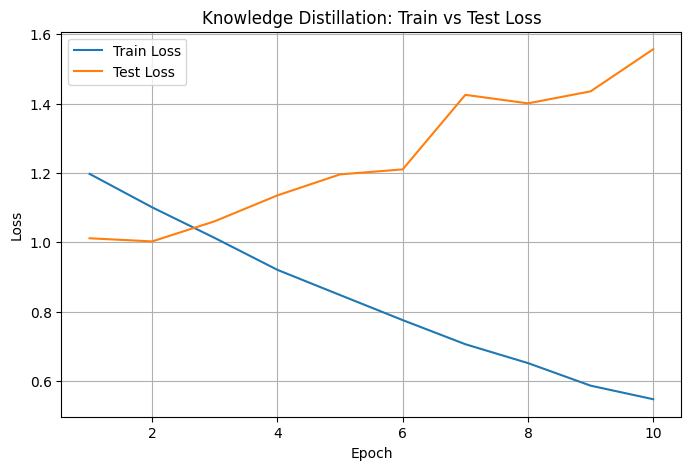

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label="Train Loss"
)

plt.plot(
    range(1, len(test_losses) + 1),
    test_losses,
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Knowledge Distillation: Train vs Test Loss")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
# =============================================================
# Mount Google Drive and save the KD-trained student model
# The file will survive after the Colab session ends and can
# be downloaded directly from your Drive.
# =============================================================
import pickle, os
from google.colab import drive

# Mount Drive (opens a browser auth prompt the first time)
drive.mount("/content/drive")

# ---- Choose where inside Drive to save ----------------------
SAVE_DIR   = "/content/drive/MyDrive/KD_models"
MODEL_PATH = os.path.join(SAVE_DIR, "kd_student_model.pkl")

os.makedirs(SAVE_DIR, exist_ok=True)

# Move to CPU so the file is device-agnostic (loads on CPU or GPU)
new_nn_light.cpu()

with open(MODEL_PATH, "wb") as f:
    pickle.dump(new_nn_light, f)

# Move back to the training device
new_nn_light.to(device)

size_mb = os.path.getsize(MODEL_PATH) / (1024 ** 2)
print(f"Model saved to Google Drive:")
print(f"  {MODEL_PATH}  ({size_mb:.2f} MB)")
print("You can download it from My Drive → KD_models → kd_student_model.pkl")

Mounted at /content/drive
Model saved to Google Drive:
  /content/drive/MyDrive/KD_models/kd_student_model.pkl  (1.03 MB)
You can download it from My Drive → KD_models → kd_student_model.pkl


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded from: /content/drive/MyDrive/KD_models/kd_student_model.pkl


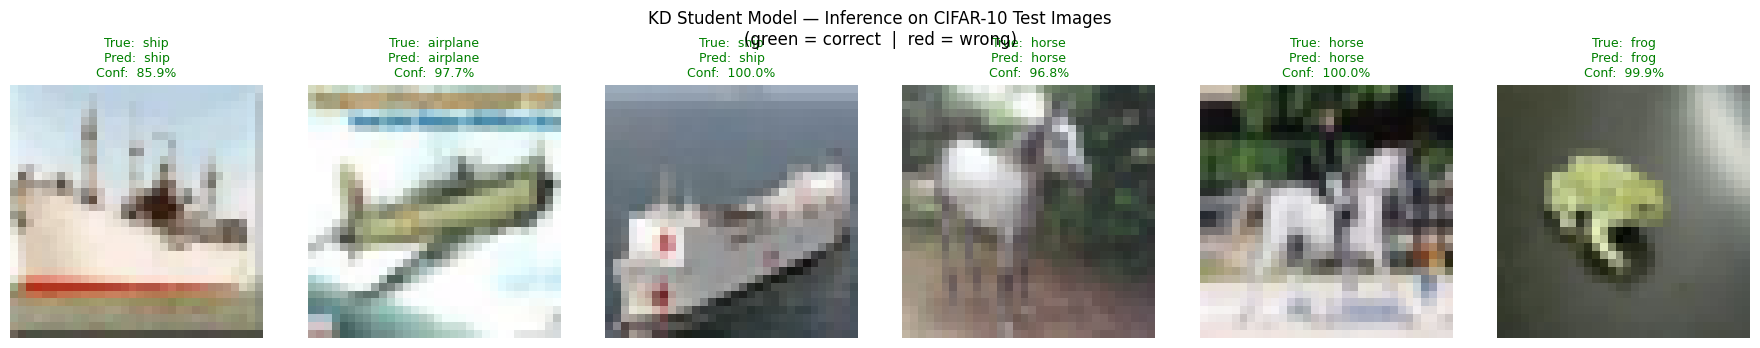


Class probabilities for the last sample:
  frog         ███████████████████████████████████████   99.9%
  bird                                                    0.1%
  dog                                                     0.0%
  cat                                                     0.0%
  ship                                                    0.0%
  airplane                                                0.0%
  truck                                                   0.0%
  automobile                                              0.0%
  deer                                                    0.0%
  horse                                                   0.0%


In [18]:
  # =============================================================
# Inference — load the saved model from Drive and predict
# =============================================================
import random, pickle
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from google.colab import drive

# Mount Drive if not already mounted
drive.mount("/content/drive")

MODEL_PATH = "/content/drive/MyDrive/KD_models/kd_student_model.pkl"

# CIFAR-10 class names
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ------------------------------------------------------------------
# 1. Load the model from Drive
# ------------------------------------------------------------------
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)

loaded_model.to(device)
loaded_model.eval()
print(f"Model loaded from: {MODEL_PATH}")

# ------------------------------------------------------------------
# 2. Pick random images from the test dataset
#    (change num_samples to preview more at once)
# ------------------------------------------------------------------
num_samples = 6
indices = random.sample(range(len(test_dataset)), num_samples)

# ------------------------------------------------------------------
# 3. Run inference and visualise results
# ------------------------------------------------------------------
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(1, num_samples, figsize=(3 * num_samples, 3.5))

for ax, idx in zip(axes, indices):
    image, true_label = test_dataset[idx]

    with torch.no_grad():
        logits     = loaded_model(image.unsqueeze(0).to(device))
        probs      = F.softmax(logits, dim=1)
        confidence, pred_idx = probs.max(dim=1)

    predicted_label = pred_idx.item()
    confidence_pct  = confidence.item() * 100

    # Denormalise for display
    img_display = (image * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

    ax.imshow(img_display)
    ax.axis("off")

    color = "green" if predicted_label == true_label else "red"
    ax.set_title(
        f"True:  {CLASS_NAMES[true_label]}\n"
        f"Pred:  {CLASS_NAMES[predicted_label]}\n"
        f"Conf:  {confidence_pct:.1f}%",
        fontsize=9, color=color
    )

fig.suptitle(
    "KD Student Model — Inference on CIFAR-10 Test Images\n"
    "(green = correct  |  red = wrong)",
    fontsize=12
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4. Per-class probability breakdown for the last sample
# ------------------------------------------------------------------
print("\nClass probabilities for the last sample:")
last_image, _ = test_dataset[indices[-1]]
last_probs = F.softmax(
    loaded_model(last_image.unsqueeze(0).to(device)), dim=1
).squeeze().cpu().tolist()

for cls, prob in sorted(zip(CLASS_NAMES, last_probs), key=lambda x: -x[1]):
    bar = "█" * int(prob * 40)
    print(f"  {cls:<12} {bar:<40} {prob * 100:5.1f}%")